# PneumoNet-Lite: Custom CNN Architecture for Chest X-Ray Pneumonia Classification

## Research Objective

This notebook develops a lightweight custom convolutional neural network (CNN) architecture for binary classification of chest X-ray images into:

- NORMAL
- PNEUMONIA

The objective is to compare a custom CNN trained from scratch against the ResNet50 transfer learning baseline developed in the previous experiment.

## Research Motivation

Although transfer learning models such as ResNet50 provide strong classification performance, they contain a large number of parameters and depend on features learned from natural image datasets.

This experiment investigates whether a lightweight CNN architecture specifically designed for chest X-ray classification can achieve competitive performance with fewer parameters.

## Proposed Model

PneumoNet-Lite is a custom CNN architecture consisting of convolutional blocks, batch normalization, global average pooling, and a fully connected classification layer.

In [37]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns

from tqdm import tqdm

# Dataset Description

The project uses the Chest X-Ray Pneumonia dataset.

The classification task consists of two classes:

| Class | Description |
|---|---|
| NORMAL | Healthy chest X-ray images |
| PNEUMONIA | Chest X-ray images showing pneumonia |

The same dataset split used for the ResNet50 baseline experiment is maintained to ensure a fair comparison.

In [38]:
import os

# Dataset path
data_dir = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"


# Folder paths
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")


# Verify paths
print("Training path:", train_dir)
print("Validation path:", val_dir)
print("Testing path:", test_dir)

Training path: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train
Validation path: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val
Testing path: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test


# Data Preprocessing and Augmentation

The same preprocessing strategy used in the ResNet50 baseline experiment is maintained to ensure a fair comparison.

The preprocessing pipeline includes:

- Image resizing to 224 × 224 pixels
- Conversion of images into tensors
- Normalization
- Data augmentation during training

Maintaining the same preprocessing pipeline allows the comparison to focus only on the difference between model architectures.

In [39]:
from torchvision import transforms


train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])


test_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [40]:
from torchvision import datasets


# Load training dataset
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)


# Load validation dataset
val_dataset = datasets.ImageFolder(
    val_dir,
    transform=test_transform
)


# Load testing dataset
test_dataset = datasets.ImageFolder(
    test_dir,
    transform=test_transform
)


# Check classes and dataset size

print("Classes:", train_dataset.classes)

print("Number of training images:", len(train_dataset))

print("Number of validation images:", len(val_dataset))

print("Number of testing images:", len(test_dataset))

Classes: ['NORMAL', 'PNEUMONIA']
Number of training images: 5216
Number of validation images: 16
Number of testing images: 624


# Creating Data Loaders

After loading and preprocessing the dataset, images are converted into batches using PyTorch DataLoader.

Data loaders allow efficient training by:

- Loading multiple images at once
- Shuffling training samples
- Reducing memory usage
- Providing batches for model optimization

A batch size of 32 is used for training the PneumoNet-Lite architecture.

In [41]:
from torch.utils.data import DataLoader


batch_size = 32


train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)


val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


print("Data loaders created successfully")

Data loaders created successfully


# Dataset Batch Verification

Before model training, a sample batch of images is inspected to verify that:

- Images are correctly loaded
- Image dimensions are appropriate
- Labels are correctly assigned

The expected image tensor format is:

(batch size, channels, height, width)

For this project:

(32, 3, 224, 224)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


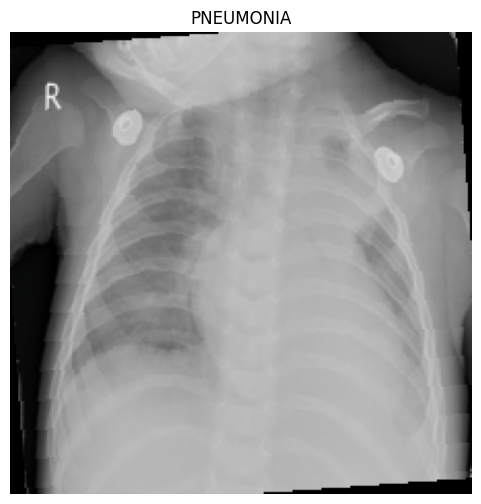

In [42]:
import matplotlib.pyplot as plt
import numpy as np


images, labels = next(iter(train_loader))


print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)


# Convert normalized image back to normal range
image = images[0].permute(1,2,0).numpy()

mean = np.array([0.485,0.456,0.406])
std = np.array([0.229,0.224,0.225])


image = std * image + mean

image = np.clip(image,0,1)


plt.figure(figsize=(6,6))

plt.imshow(image)

plt.title(train_dataset.classes[labels[0]])

plt.axis("off")

plt.show()

# Proposed PneumoNet-Lite Custom CNN Architecture

In this experiment, a lightweight custom convolutional neural network (CNN) named **PneumoNet-Lite** is developed for chest X-ray pneumonia classification.

The purpose of this architecture is to compare a task-specific CNN trained from scratch against the ResNet50 transfer learning baseline.

Unlike ResNet50, which contains approximately 23.5 million parameters and uses ImageNet pretrained features, PneumoNet-Lite is designed with fewer parameters and learns features directly from chest X-ray images.

## Architecture Design

The proposed model consists of:

- Five convolutional feature extraction blocks
- Batch normalization for training stability
- ReLU activation functions
- Max pooling for feature reduction
- Global average pooling for reducing parameters
- Dropout regularization
- Fully connected binary classification layer

The final output predicts:

- NORMAL
- PNEUMONIA

The research objective is to analyze the trade-off between model complexity, efficiency, and classification performance.

In [43]:
import torch
import torch.nn as nn


class ConvBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        
        super(ConvBlock, self).__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),


            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),


            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )


    def forward(self, x):

        return self.block(x)

# Complete PneumoNet-Lite Architecture

The ConvBlock components are combined to create the complete PneumoNet-Lite classification model.

The architecture follows a progressive feature extraction strategy:

Input Image (224×224×3)

↓

Convolutional Feature Extraction Blocks

↓

Global Average Pooling

↓

Fully Connected Classifier

↓

Binary Output (NORMAL / PNEUMONIA)


The model contains:

- Four convolutional feature extraction blocks
- Increasing feature channels (32 → 64 → 128 → 256)
- Global Average Pooling to reduce parameters
- Dropout regularization to reduce overfitting
- Single output neuron for binary classification

In [44]:
class PneumoNetLite(nn.Module):

    def __init__(self):

        super(PneumoNetLite, self).__init__()


        # Feature extraction blocks

        self.features = nn.Sequential(

            ConvBlock(3, 32),

            ConvBlock(32, 64),

            ConvBlock(64, 128),

            ConvBlock(128, 256)

        )


        # Reduce spatial dimensions

        self.global_pool = nn.AdaptiveAvgPool2d(1)


        # Classification head

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256, 128),

            nn.ReLU(inplace=True),

            nn.Dropout(0.5),

            nn.Linear(128, 1)

        )


    def forward(self, x):

        x = self.features(x)

        x = self.global_pool(x)

        x = self.classifier(x)

        return x

# Device Configuration

Deep learning models require significant computational resources during training.

This experiment uses GPU acceleration when available. If GPU is unavailable, the model will automatically run on CPU.

The selected device is displayed before training.

In [45]:
import torch


# Check GPU availability

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


print("Using device:", device)


if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [46]:
# Initialize PneumoNet-Lite model

model = PneumoNetLite()

model = model.to(device)


print(model)

PneumoNetLite(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_

In [47]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)


trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print(f"Total parameters: {total_params:,}")

print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 1,207,201
Trainable parameters: 1,207,201


# Class Distribution Analysis and Weighted Loss

Medical image datasets often contain an unequal number of samples between classes.

In this dataset, pneumonia-positive images are more frequent than normal images. Class imbalance can cause a model to become biased toward the majority class.

To reduce this effect, a weighted loss strategy is applied.

The weighted Binary Cross Entropy loss assigns higher importance to the minority class during training.

The same weighted loss strategy used in the ResNet50 baseline experiment is applied to PneumoNet-Lite for a fair comparison.

In [48]:
from collections import Counter


# Get training labels

train_labels = [
    label for _, label in train_dataset.samples
]


# Count classes

class_counts = Counter(train_labels)


print("Class distribution:")

for class_idx, count in class_counts.items():
    print(
        train_dataset.classes[class_idx],
        ":",
        count
    )

Class distribution:
NORMAL : 1341
PNEUMONIA : 3875


In [49]:
# Extract counts

normal_count = class_counts[0]

pneumonia_count = class_counts[1]


# Calculate positive class weight

pos_weight = torch.tensor(
    [normal_count / pneumonia_count],
    dtype=torch.float
).to(device)


print("Positive class weight:", pos_weight)

Positive class weight: tensor([0.3461], device='cuda:0')


# Training Configuration

The PneumoNet-Lite model is trained as a binary classification model.

Training configuration:

- Loss Function: Binary Cross Entropy with Logits Loss
- Optimizer: Adam
- Learning Rate: 0.001
- Batch Size: 32
- Epochs: 50

The model performance is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score

The same evaluation metrics used for the ResNet50 baseline are maintained to ensure a fair comparison.

In [50]:
import torch.optim as optim


# Loss function
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)


# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


# Number of epochs
epochs = 50

# Model Training Function

A training pipeline is developed to optimize PneumoNet-Lite using the weighted binary cross-entropy loss.

During training, the model performance is monitored on both training and validation datasets.

The following metrics are recorded:

- Training loss
- Validation loss
- Training F1-score
- Validation F1-score

These metrics are later used for performance analysis and comparison with the ResNet50 baseline.

In [51]:
from sklearn.metrics import f1_score


def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0.0
    predictions = []
    targets = []


    for images, labels in loader:

        images = images.to(device)

        labels = labels.float().to(device)


        optimizer.zero_grad()


        outputs = model(images)

        outputs = outputs.squeeze()


        loss = criterion(outputs, labels)


        loss.backward()

        optimizer.step()


        running_loss += loss.item()


        preds = torch.sigmoid(outputs)

        preds = (preds >= 0.5).int()


        predictions.extend(
            preds.cpu().numpy()
        )

        targets.extend(
            labels.cpu().numpy()
        )


    epoch_loss = running_loss / len(loader)


    epoch_f1 = f1_score(
        targets,
        predictions
    )


    return epoch_loss, epoch_f1

# Validation Function

After each training epoch, the trained model is evaluated on the validation dataset.

The validation process measures:

- Validation loss
- Validation F1-score

The validation results are used to monitor model generalization and identify potential overfitting during training.

In [52]:
def validate_model(model, loader, criterion):

    model.eval()

    running_loss = 0.0

    predictions = []

    targets = []


    with torch.no_grad():

        for images, labels in loader:


            images = images.to(device)

            labels = labels.float().to(device)


            outputs = model(images)

            outputs = outputs.squeeze()


            loss = criterion(
                outputs,
                labels
            )


            running_loss += loss.item()


            preds = torch.sigmoid(outputs)

            preds = (preds >= 0.5).int()


            predictions.extend(
                preds.cpu().numpy()
            )


            targets.extend(
                labels.cpu().numpy()
            )


    val_loss = running_loss / len(loader)


    val_f1 = f1_score(
        targets,
        predictions
    )


    return val_loss, val_f1

# Model Training

The PneumoNet-Lite model is trained using the weighted binary cross-entropy loss function.

During each epoch:

1. Training images are passed through the CNN.
2. The predicted outputs are compared with true labels.
3. Loss is calculated.
4. Backpropagation updates model parameters.
5. Validation performance is measured after each epoch.

The model with the best validation F1-score is saved for final evaluation.

Training history is stored for later visualization and comparison with the ResNet50 baseline.

In [53]:
# Training history storage

train_losses = []
val_losses = []

train_f1_scores = []
val_f1_scores = []


# Number of epochs

epochs = 50


# Best validation score tracking

best_val_f1 = 0.0


# Training loop

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")


    # Training

    train_loss, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )


    # Validation

    val_loss, val_f1 = validate_model(
        model,
        val_loader,
        criterion
    )


    # Store history

    train_losses.append(train_loss)

    val_losses.append(val_loss)

    train_f1_scores.append(train_f1)

    val_f1_scores.append(val_f1)



    print(
        f"Training Loss: {train_loss:.4f} | "
        f"Training F1: {train_f1:.4f}"
    )


    print(
        f"Validation Loss: {val_loss:.4f} | "
        f"Validation F1: {val_f1:.4f}"
    )



    # Save best model

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1


        torch.save(
            model.state_dict(),
            "pneumonet_lite_best.pth"
        )


        print("Best model saved!")


Epoch 1/50
Training Loss: 0.1514 | Training F1: 0.9080
Validation Loss: 0.5548 | Validation F1: 0.7778
Best model saved!

Epoch 2/50
Training Loss: 0.1000 | Training F1: 0.9459
Validation Loss: 1.6692 | Validation F1: 0.7273

Epoch 3/50
Training Loss: 0.0929 | Training F1: 0.9527
Validation Loss: 0.4326 | Validation F1: 0.7368

Epoch 4/50
Training Loss: 0.0810 | Training F1: 0.9569
Validation Loss: 0.2574 | Validation F1: 0.8000
Best model saved!

Epoch 5/50
Training Loss: 0.0778 | Training F1: 0.9598
Validation Loss: 0.5582 | Validation F1: 0.8750
Best model saved!

Epoch 6/50
Training Loss: 0.0789 | Training F1: 0.9604
Validation Loss: 1.7349 | Validation F1: 0.6957

Epoch 7/50
Training Loss: 0.0677 | Training F1: 0.9639
Validation Loss: 0.7655 | Validation F1: 0.8000

Epoch 8/50
Training Loss: 0.0603 | Training F1: 0.9682
Validation Loss: 0.4206 | Validation F1: 0.8750

Epoch 9/50
Training Loss: 0.0636 | Training F1: 0.9664
Validation Loss: 0.3719 | Validation F1: 0.7143

Epoch 10/

# Training Performance Visualization

The training history of PneumoNet-Lite is analyzed using loss and F1-score curves.

The visualization helps evaluate:

- Model convergence
- Training stability
- Possible overfitting
- Performance improvement during epochs

Two plots are generated:

1. Training and validation loss curve
2. Training and validation F1-score curve

These plots are used for model analysis and comparison with the ResNet50 baseline experiment.

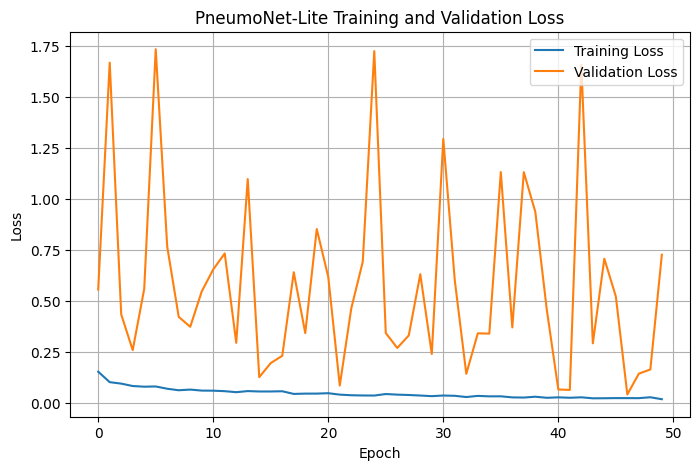

In [54]:
import matplotlib.pyplot as plt


# Plot loss curves

plt.figure(figsize=(8,5))


plt.plot(
    train_losses,
    label="Training Loss"
)


plt.plot(
    val_losses,
    label="Validation Loss"
)


plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "PneumoNet-Lite Training and Validation Loss"
)

plt.legend()

plt.grid(True)


plt.savefig(
    "custom_cnn_training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

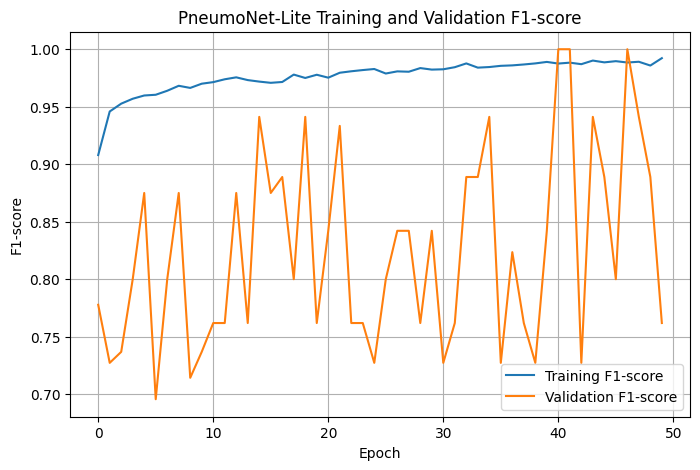

In [56]:
plt.figure(figsize=(8,5))


plt.plot(
    train_f1_scores,
    label="Training F1-score"
)


plt.plot(
    val_f1_scores,
    label="Validation F1-score"
)


plt.xlabel("Epoch")


plt.ylabel("F1-score")


plt.title(
    "PneumoNet-Lite Training and Validation F1-score"
)


plt.legend()

plt.grid(True)


plt.savefig(
    "custom_cnn_training_validation_f1.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# Model Evaluation on Test Dataset

After training, the best-performing PneumoNet-Lite model is evaluated on the unseen test dataset.

The test dataset is not used during training or model selection, allowing an unbiased evaluation of classification performance.

The following evaluation metrics are calculated:

- Accuracy
- Precision
- Recall
- F1-score

A confusion matrix is also generated to analyze correct and incorrect predictions for both classes:

- NORMAL
- PNEUMONIA

In [57]:
# Load the best saved PneumoNet-Lite model

best_model = PneumoNetLite()

best_model.load_state_dict(
    torch.load(
        "pneumonet_lite_best.pth",
        map_location=device
    )
)


best_model = best_model.to(device)


best_model.eval()


print("Best PneumoNet-Lite model loaded successfully")

Best PneumoNet-Lite model loaded successfully


In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


all_predictions = []

all_labels = []


with torch.no_grad():

    for images, labels in test_loader:


        images = images.to(device)


        outputs = best_model(images)


        outputs = outputs.squeeze()


        probabilities = torch.sigmoid(outputs)


        predictions = (
            probabilities >= 0.5
        ).int()


        all_predictions.extend(
            predictions.cpu().numpy()
        )


        all_labels.extend(
            labels.numpy()
        )


print("Testing completed")

Testing completed


In [59]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)


precision = precision_score(
    all_labels,
    all_predictions
)


recall = recall_score(
    all_labels,
    all_predictions
)


f1 = f1_score(
    all_labels,
    all_predictions
)



print("Test Accuracy:", round(accuracy,4))

print("Test Precision:", round(precision,4))

print("Test Recall:", round(recall,4))

print("Test F1-score:", round(f1,4))

Test Accuracy: 0.8846
Test Precision: 0.8698
Test Recall: 0.959
Test F1-score: 0.9122


In [60]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=train_dataset.classes
    )
)

              precision    recall  f1-score   support

      NORMAL       0.92      0.76      0.83       234
   PNEUMONIA       0.87      0.96      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.86      0.87       624
weighted avg       0.89      0.88      0.88       624



In [61]:
import pandas as pd


metrics_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]

})


metrics_df.to_csv(
    "pneumonet_lite_test_metrics.csv",
    index=False
)


metrics_df

,Metric,Value
0,Accuracy,0.884615
1,Precision,0.869767
2,Recall,0.958974
3,F1-score,0.912195


# Confusion Matrix Analysis

A confusion matrix is generated to visualize the classification performance of PneumoNet-Lite on the independent test dataset.

The matrix provides detailed information about:

- True Negative (correct NORMAL predictions)
- False Positive (NORMAL predicted as PNEUMONIA)
- False Negative (PNEUMONIA predicted as NORMAL)
- True Positive (correct PNEUMONIA predictions)

This analysis provides deeper insight into model reliability beyond overall performance metrics.

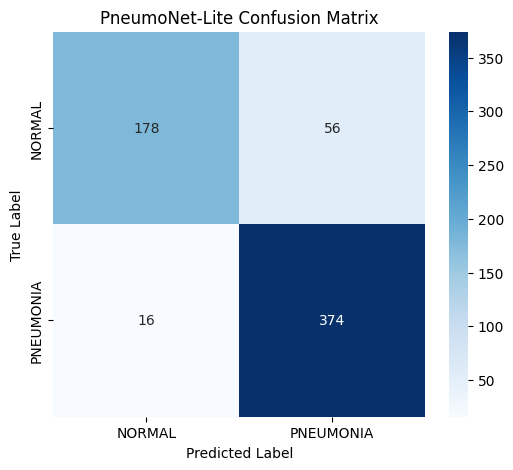

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns


# Generate confusion matrix

cm = confusion_matrix(
    all_labels,
    all_predictions
)


# Display confusion matrix

plt.figure(figsize=(6,5))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)


plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title(
    "PneumoNet-Lite Confusion Matrix"
)


plt.savefig(
    "pneumonet_lite_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

# Saving Final Model and Research Comparison

The trained PneumoNet-Lite model and experimental results are saved for reproducibility.

The final artifacts include:

- Trained model weights
- Test performance metrics
- Comparison with the ResNet50 baseline model

The comparison evaluates the trade-off between classification performance and model complexity.

In [63]:
# Save final PneumoNet-Lite model

torch.save(
    best_model.state_dict(),
    "pneumonet_lite_final.pth"
)


print("Final model saved successfully")

Final model saved successfully


In [64]:
import pandas as pd


pneumonet_results = pd.DataFrame({

    "Model": [
        "PneumoNet-Lite"
    ],

    "Parameters": [
        "1,207,201"
    ],

    "Accuracy": [
        accuracy
    ],

    "Precision": [
        precision
    ],

    "Recall": [
        recall
    ],

    "F1-score": [
        f1
    ]

})


pneumonet_results

,Model,Parameters,Accuracy,Precision,Recall,F1-score
0,PneumoNet-Lite,"1,207,201",0.884615,0.869767,0.958974,0.912195


In [65]:
pneumonet_results.to_csv(
    "pneumonet_lite_results_summary.csv",
    index=False
)


print("Results CSV saved")

Results CSV saved


In [66]:
comparison = pd.DataFrame({

    "Model": [
        "ResNet50 Transfer Learning",
        "PneumoNet-Lite Custom CNN"
    ],

    "Parameters": [
        "23.5 Million",
        "1.2 Million"
    ],

    "Accuracy": [
        0.7997,
        accuracy
    ],

    "Precision": [
        "Baseline Result",
        precision
    ],

    "Recall": [
        1.0000,
        recall
    ],

    "F1-score": [
        0.8619,
        f1
    ]

})


comparison

,Model,Parameters,Accuracy,Precision,Recall,F1-score
0,ResNet50 Transfer Learning,23.5 Million,0.799700,Baseline Result,1.000000,0.861900
1,PneumoNet-Lite Custom CNN,1.2 Million,0.884615,0.869767,0.958974,0.912195


In [67]:
comparison.to_csv(
    "resnet50_vs_pneumonet_comparison.csv",
    index=False
)


print("Comparison table saved")

Comparison table saved


# Research Summary and Findings

This study developed PneumoNet-Lite, a lightweight custom convolutional neural network for chest X-ray pneumonia classification.

The proposed model was evaluated against a ResNet50 transfer learning baseline using the same dataset and evaluation metrics.

Key findings:

- PneumoNet-Lite achieved 88.46% test accuracy.
- The model achieved an F1-score of 91.22%.
- The proposed architecture used approximately 1.2 million parameters, significantly fewer than ResNet50.
- The lightweight architecture demonstrates potential for efficient medical image classification applications.

Although the model achieved competitive performance, the small validation subset of the dataset remains a limitation and future work should evaluate the architecture on larger and more diverse medical imaging datasets.